In [ ]:
# from google.colab import drive
# import sys

# drive.mount('/content/drive')
# sys.path.append('/content/drive/MyDrive/colab_libraries')

# # Now you can import immediately
# from meridian.model import model

In [ ]:
!pip install --upgrade "google-meridian[colab,and-cuda,schema]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.3/491.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.1/935.1 kB 14.8 MB/s eta 0:00:00
  Attempting uninstall: natsort
    Found existing installation: natsort 8.4.0
    Uninstalling natsort-8.4.0:
      Successfully uninstalled natsort-8.4.0
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0


In [ ]:
# 2. Import core libraries
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import arviz as az

# 3. Import Meridian modules
import meridian
from meridian import constants
from meridian.analysis import analyzer
from meridian.analysis import optimizer
from meridian.analysis import summarizer
from meridian.analysis import visualizer
from meridian.analysis.review import reviewer
from meridian.data import data_frame_input_data_builder
from meridian.model import model
from meridian.model import prior_distribution
from meridian.model import spec
from meridian.model import transformers
from meridian.schema.serde import meridian_serde

from meridian.model import prior_distribution
import tensorflow_probability as tfp

In [ ]:
# 4. Verify GPU Connection
# Meridian relies on XLA (Accelerated Linear Algebra) to run the Bayesian math.
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please check Runtime > Change runtime type.')
else:
  print(f'Found GPU at: {device_name}')

# 5. Print version to confirm successful installation
print(f"Meridian Version: {meridian.__version__}")

Found GPU at: /device:GPU:0
Meridian Version: 1.6.1


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.cloud import bigquery
#Authenticate
from google.colab import auth
auth.authenticate_user()

# Set your GCP project (REPLACE)
project_id = "freedom-solar-406415"
location = 'US'

client = bigquery.Client(project=project_id, location=location)

In [ ]:
query = """
WITH base AS (
SELECT
    DATE_TRUNC(Date, WEEK(MONDAY)) AS date,
    Region as geo,
    SUM(CASE WHEN Type = 'Brand'       THEN Cost ELSE 0 END) AS Brand_Cost,
    SUM(CASE WHEN Type = 'Non-Brand'   THEN Cost ELSE 0 END) AS Non_Brand_Cost,
    SUM(CASE WHEN Type = 'DVD'         THEN Cost ELSE 0 END) AS DVD_Cost,
    SUM(CASE WHEN Type = 'Retargeting' THEN Cost ELSE 0 END) AS Retargeting_Cost,
    SUM(CASE WHEN Type = 'Prospecting' THEN Cost ELSE 0 END) AS Prospecting_Cost,
    SUM(CASE WHEN Type = 'Brand'       THEN Impressions ELSE 0 END) AS Brand_Impressions,
    SUM(CASE WHEN Type = 'Non-Brand'   THEN Impressions ELSE 0 END) AS Non_Brand_Impressions,
    SUM(CASE WHEN Type = 'DVD'         THEN Impressions ELSE 0 END) AS DVD_Impressions,
    SUM(CASE WHEN Type = 'Retargeting' THEN Impressions ELSE 0 END) AS Retargeting_Impressions,
    SUM(CASE WHEN Type = 'Prospecting' THEN Impressions ELSE 0 END) AS Prospecting_Impressions,
    NULL AS Reddit_Cost,
    NULL AS Reddit_Impressions,
    SUM(Gross_Leads_New) AS Gross_Leads
FROM `freedom_solar_agg.full_funnel_unmatched`
WHERE Date >= "2024-01-01"
AND Region != "Other"
GROUP BY date, geo

UNION ALL

SELECT
    DATE_TRUNC(Date, WEEK(MONDAY)) AS date,
    Region as geo,
    SUM(CASE WHEN Type = 'Brand'       THEN Cost ELSE 0 END) AS Brand_Cost,
    SUM(CASE WHEN Type = 'Non-Brand'   THEN Cost ELSE 0 END) AS Non_Brand_Cost,
    SUM(CASE WHEN Type = 'DVD'         THEN Cost ELSE 0 END) AS DVD_Cost,
    SUM(CASE WHEN Type = 'Retargeting' THEN Cost ELSE 0 END) AS Retargeting_Cost,
    SUM(CASE WHEN Type = 'Prospecting' THEN Cost ELSE 0 END) AS Prospecting_Cost,
    SUM(CASE WHEN Type = 'Brand'       THEN Impressions ELSE 0 END) AS Brand_Impressions,
    SUM(CASE WHEN Type = 'Non-Brand'   THEN Impressions ELSE 0 END) AS Non_Brand_Impressions,
    SUM(CASE WHEN Type = 'DVD'         THEN Impressions ELSE 0 END) AS DVD_Impressions,
    SUM(CASE WHEN Type = 'Retargeting' THEN Impressions ELSE 0 END) AS Retargeting_Impressions,
    SUM(CASE WHEN Type = 'Prospecting' THEN Impressions ELSE 0 END) AS Prospecting_Impressions,
    NULL AS Reddit_Cost,
    NULL AS Reddit_Impressions,
    SUM(Gross_Leads) AS Gross_Leads
FROM `freedom-solar-406415.freedom_solar_hvac.full_funnel_HVAC`
WHERE Date >= "2024-01-01"
AND Region != "Other"
GROUP BY date, geo

UNION ALL

SELECT
    DATE_TRUNC(Date, WEEK(MONDAY)) AS date,
    Region as geo,
    NULL AS Brand_Cost,
    NULL AS Non_Brand_Cost,
    NULL AS DVD_Cost,
    NULL AS Retargeting_Cost,
    NULL AS Prospecting_Cost,
    NULL AS Brand_Impressions,
    NULL AS Non_Brand_Impressions,
    NULL AS DVD_Impressions,
    NULL AS Retargeting_Impressions,
    NULL AS Prospecting_Impressions,
    SUM(Cost) AS Reddit_Cost,
    SUM(Impressions) AS Reddit_Impressions,
    NULL AS Gross_Leads
FROM `freedom-solar-406415.freedom_solar_segments.reddit_data`
WHERE Date >= "2024-01-01"
AND Region != "Other"
GROUP BY date, geo
)

SELECT
    date,
    geo,
    SUM(Brand_Cost) AS Brand_Cost,
    SUM(Non_Brand_Cost) AS Non_Brand_Cost,
    SUM(DVD_Cost) AS DVD_Cost,
    SUM(Retargeting_Cost) AS Retargeting_Cost,
    SUM(Prospecting_Cost) AS Prospecting_Cost,
    SUM(Brand_Impressions) AS Brand_Impressions,
    SUM(Non_Brand_Impressions) AS Non_Brand_Impressions,
    SUM(DVD_Impressions) AS DVD_Impressions,
    SUM(Retargeting_Impressions) AS Retargeting_Impressions,
    SUM(Prospecting_Impressions) AS Prospecting_Impressions,
    SUM(Reddit_Cost) AS Reddit_Cost,
    SUM(Reddit_Impressions) AS Reddit_Impressions,
    SUM(Gross_Leads) AS Gross_Leads
FROM base
WHERE Date < CURRENT_DATE()
GROUP BY date, geo
ORDER BY date, geo
"""

In [ ]:
BQ_pull = client.query(query).to_dataframe()

In [ ]:
raw_data = BQ_pull.copy()

### Add in Context Variables

Tax Credit

In [ ]:
# Tax credit regime shift indicator
policy_change_date = pd.Timestamp("2025-10-01")

raw_data["tax_credit_shift"] = (
    raw_data["date"] >= policy_change_date
).astype(np.float32)

Storm Dates

In [ ]:
# Acute spike period
raw_data["storm_acute"] = (
    (raw_data["date"] >= pd.Timestamp("2024-05-15")) &
    (raw_data["date"] < pd.Timestamp("2024-07-15"))
).astype(np.float32)

# Elevated tail as installs/leads work through the pipeline
raw_data["storm_tail"] = (
    (raw_data["date"] >= pd.Timestamp("2024-07-15")) &
    (raw_data["date"] < pd.Timestamp("2024-09-01"))
).astype(np.float32)

### Ensure we have rows for all dates/geos

In [ ]:
# 1. Ensure 'date' is a proper datetime object
raw_data['date'] = pd.to_datetime(raw_data['date'])

# 2. Get the unique list of all dates and all geos
all_dates = raw_data['date'].unique()
all_geos = raw_data['geo'].unique()

# 3. Create a 'Perfect Index' of all possible combinations
perfect_index = pd.MultiIndex.from_product(
    [all_dates, all_geos],
    names=['date', 'geo']
)
perfect_df = pd.DataFrame(index=perfect_index).reset_index()

# 4. Merge your data into the perfect structure
# Use 'left' join so we keep every date/geo combo, filling missing with 0
raw_data = pd.merge(perfect_df, raw_data, on=['date', 'geo'], how='left').fillna(0)

# 5. Sort to ensure alignment (VERY important for Meridian)
raw_data = raw_data.sort_values(['geo', 'date']).reset_index(drop=True)

print(f"Data Re-aligned! Total rows should be {len(all_dates) * len(all_geos)}.")
print(f"Current rows: {len(raw_data)}")

Data Re-aligned! Total rows should be 1488.
Current rows: 1488


In [ ]:
# Create a list of the low-volume geos we identified
geos_to_drop = ['Carolinas', 'Denver', 'Virginia', 'Colorado Springs', 'Richmond', 'OOT']

# Filter the dataframe to keep only rows where the geo is NOT in that list
raw_data = raw_data[~raw_data['geo'].isin(geos_to_drop)].reset_index(drop=True)

# Verify the change
print(f"Remaining regions: {raw_data['geo'].unique()}")

Remaining regions: ['Austin' 'DFW' 'Houston' 'Orlando' 'San Antonio' 'Tampa']


### Assign populations to each geo

In [ ]:
# Create the mapping dictionary
dma_population_map = {
    'DFW': 3264490,
    'Houston': 2797420,
    'Tampa': 2221240,
    'Orlando': 1902420,
    'Denver': 1806270,
    'Carolinas': 1382020,
    'San Antonio': 1096400,
    'Austin': 1029800,
    'Virginia': 625380,
    'Colorado Springs': 388730
}

# Assign to your dataframe
# This looks at your 'geo' column and creates a 'population' column based on the map
raw_data['population'] = raw_data['geo'].map(dma_population_map)

# Double check for any missing values (typos in geo names)
missing_count = raw_data['population'].isna().sum()
if missing_count > 0:
    print(f"Warning: {missing_count} rows have no population mapping. Check your geo names!")
else:
    print("Population mapping successful!")

Population mapping successful!


In [ ]:
raw_data.date.min()

Timestamp('2024-01-01 00:00:00')

In [ ]:
all_dates = pd.to_datetime(raw_data['date'].unique())
min_date = all_dates.min()
max_date = all_dates.max()

# Create a full date range starting from the min date of raw_data to the max date, weekly
weekly_dates = pd.date_range(start=min_date, end=max_date, freq='W-MON')

# Initialize the manual DataFrame with all dates and 'Austin' geo
manual_df = pd.DataFrame({
    'date': weekly_dates,
    'geo': 'Austin'
})

# Set default values for new columns
manual_df['Billboard_Cost'] = 0.0
manual_df['Billboard_Impressions'] = 0.0
manual_df['DirectMail_Impressions'] = 0.0

# Billboard Campaign Details
billboard_start_date = pd.Timestamp('2026-03-02') # Adjusted to Monday for weekly alignment
billboard_end_date = max_date # 'finishes later this month' implies until the end of raw_data
billboard_cost_per_week = 32900
billboard_impressions_per_week = 845515

# Populate billboard data for the specified period
billboard_mask = (manual_df['date'] >= billboard_start_date) & (manual_df['date'] <= billboard_end_date)
manual_df.loc[billboard_mask, 'Billboard_Cost'] = billboard_cost_per_week
manual_df.loc[billboard_mask, 'Billboard_Impressions'] = billboard_impressions_per_week

# Direct Mail Campaign Details
direct_mail_date = pd.Timestamp('2026-03-30') # Corrected to Monday for weekly alignment from 3/30/2025
direct_mail_impressions = 20000

# Populate direct mail data for the specified week
direct_mail_mask = (manual_df['date'] == direct_mail_date)
manual_df.loc[direct_mail_mask, 'DirectMail_Impressions'] = direct_mail_impressions

manual_df.tail(6)

,date,geo,Billboard_Cost,Billboard_Impressions,DirectMail_Impressions
118,2026-04-06,Austin,32900.0,845515.0,0.0
119,2026-04-13,Austin,32900.0,845515.0,0.0
120,2026-04-20,Austin,32900.0,845515.0,0.0
121,2026-04-27,Austin,32900.0,845515.0,0.0
122,2026-05-04,Austin,32900.0,845515.0,0.0
123,2026-05-11,Austin,32900.0,845515.0,0.0


In [ ]:
raw_data = pd.merge(raw_data, manual_df, on=['date', 'geo'], how='left')
raw_data = raw_data.fillna(0)

In [ ]:
raw_data.to_csv('Freedom_MMM_data_Apr26.csv')

### Build Transformers

### Build Priors

In [ ]:
# ==========================================================
# 1. CHANNELS + TYPE CASTING (NO MANUAL SCALING)
# ==========================================================
channels = ['Non_Brand', 'Brand', 'DVD', 'Retargeting', 'Prospecting', 'Billboard']

# KPI: just cast to float32 (Meridian will scale internally)
raw_data['Gross_Leads'] = raw_data['Gross_Leads'].astype(np.float32)

# Media: just cast to float32 (Meridian will scale internally)
for chan in channels:
    raw_data[f'{chan}_Cost'] = raw_data[f'{chan}_Cost'].astype(np.float32)
    raw_data[f'{chan}_Impressions'] = raw_data[f'{chan}_Impressions'].astype(np.float32)

# Population: cast to float32
raw_data['population'] = raw_data['population'].astype(np.float32)

In [ ]:
# ==========================================================
# 2. INPUT DATA BUILDER
# ==========================================================

# Define your organic channels separately from paid channels
organic_channels = ['DirectMail']  # adjust to your actual channel names

builder = data_frame_input_data_builder.DataFrameInputDataBuilder(kpi_type='non_revenue')

builder = builder.with_kpi(
    raw_data,
    kpi_col='Gross_Leads',
    time_col='date',
    geo_col='geo'
)

builder = builder.with_media(
    raw_data,
    media_channels=channels,
    media_spend_cols=[f'{c}_Cost' for c in channels],
    media_cols=[f'{c}_Impressions' for c in channels],
    time_col='date',
    geo_col='geo'
)

# ✅ ADD ORGANIC MEDIA — no spend cols, impressions/clicks only
# builder = builder.with_organic_media(
#     raw_data,
#     organic_media_cols=[f"{c}_Impressions" for c in organic_channels],
#     organic_media_channels=organic_channels,
#     media_time_col="date",
#     geo_col="geo",
# )

builder = builder.with_controls(
    raw_data,
    control_cols=["tax_credit_shift", "storm_acute", "storm_tail"],
    time_col="date",
    geo_col="geo"
)


builder = builder.with_population(
    raw_data,
    population_col='population',
    geo_col='geo'
)

input_data = builder.build()

/usr/local/lib/python3.12/dist-packages/meridian/data/input_data.py:525: UserWarning: Consider setting custom priors, as kpi_type was specified as `non_revenue` with no `revenue_per_kpi` being set. Otherwise, the total media contribution prior will be used with `p_mean=0.4` and `p_sd=0.2`. Further documentation available at https://developers.google.com/meridian/docs/advanced-modeling/unknown-revenue-kpi-custom#set-total-paid-media-contribution-prior
  warnings.warn(


In [ ]:
# ==========================================================
# 3. PRIOR SPECIFICATION (Contribution-prior mode)
# ==========================================================
# Per-channel contribution priors (mean share of total conversions)
# Baseline covers the remainder (~34%)
channel_priors = {
    'Prospecting':  0.26,
    'Non_Brand':    0.20,
    'Brand':        0.10,  # lowered from 0.14 — demand capturer, not creator
    'Retargeting':  0.05,
    'DVD':          0.06,
    'Billboard':    0.01,
}

# Per-channel kappa (κ) — controls tightness around the prior mean
# Higher = tighter. Brand is intentionally constrained given fixed-spend,
# demand-capture nature. Billboard loosened as a newer channel.
kappas = {
    'Prospecting':  100.0,
    'Non_Brand':    75.0,
    'Brand':        150.0,
    'Retargeting':  150.0,
    'DVD':          50.0,
    'Billboard':    30.0,
}

concentration1 = tf.cast(
    [channel_priors[c] * kappas[c] for c in channels], tf.float32
)
concentration0 = tf.cast(
    [(1.0 - channel_priors[c]) * kappas[c] for c in channels], tf.float32
)

my_priors = prior_distribution.PriorDistribution(
    contribution_m=tfp.distributions.Beta(
        concentration1=concentration1,
        concentration0=concentration0,
    )
)

In [ ]:
n_weeks = len(raw_data['date'].unique())

### Modify Knots (Apr 9th 2026)

In [ ]:
# # AKS selected knots
# aks_knots = np.array([14, 17, 22, 26, 27, 30, 31, 33, 35, 39, 40, 41, 45, 47, 53, 60, 70, 83, 93, 104, 107, 109, 116])

# # Add early coverage, thin the dense mid-2024 cluster
# add_knots = np.array([1, 4, 8, 11])          # cover Jan–Mar 2024
# remove_knots = np.array([27, 31, 40, 41])    # thin the over-dense spike region

# modified_knots = np.setdiff1d(
#     np.append(aks_knots, add_knots),
#     remove_knots
# )
# modified_knots = np.sort(modified_knots)

In [ ]:
# ==========================================================
# 4. MODEL SPEC & EXECUTION
# ==========================================================

model_spec = spec.ModelSpec(
    prior=my_priors,
    media_prior_type='contribution',
    enable_aks=True,
    # knots=modified_knots,
    max_lag=4,
    media_effects_dist='log_normal'
)

mmm = model.Meridian(input_data=input_data, model_spec=model_spec)

#### Model Spec with Holdout

In [ ]:
# # ==========================================================
# # HOLDOUT SETUP (Time-based) — Meridian expects shape (n_geos, n_times)
# # ==========================================================
# holdout_weeks = 4

# # Make sure ordering matches your builder: sort by geo then date
# df = raw_data.sort_values(["geo", "date"]).reset_index(drop=True)

# # Identify the last N time points (global across geos)
# dates = np.sort(df["date"].unique())
# holdout_start_date = dates[-holdout_weeks]

# # Create a 2D holdout mask: (n_geos, n_times)
# # Same dates are held out for every geo
# holdout_time = (dates >= holdout_start_date).astype(int)          # shape (n_times,)
# holdout_id = np.tile(holdout_time, (df["geo"].nunique(), 1))      # shape (n_geos, n_times)

# # ==========================================================
# # MODEL SPEC WITH HOLDOUT
# # ==========================================================
# model_spec = spec.ModelSpec(
#     prior=my_priors,
#     media_prior_type='contribution',
#     knots=n_weeks // 2,
#     max_lag=4,
#     media_effects_dist='log_normal',
#     holdout_id=holdout_id
# )

# mmm = model.Meridian(input_data=input_data, model_spec=model_spec)

### Run Model

In [ ]:
# Sample
mmm.sample_prior(1000)
mmm.sample_posterior(
    n_chains=4,
    n_adapt=1000,
    n_burnin=1000,
    n_keep=2000,
    seed=42
)

/usr/local/lib/python3.12/dist-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


### Review Model

In [ ]:
reviewer.ModelReviewer(mmm).run()

/tmp/ipykernel_8135/3363694858.py:1: DeprecationWarning: The `meridian` argument is deprecated. Please use `model_context` and `inference_data` instead.
  reviewer.ModelReviewer(mmm).run()
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1040: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:678: RuntimeWarning: divide by zero encountered in divide
  return backend.nanmean(backend.absolute((actual - expected) / actual))


Model Quality Checks
Overall Status: PASS
Summary: Passed: No major quality issues were identified.
Health Score: 99.8

Check Results:
----------------------------------------
Convergence Check:
  Status: PASS
  Recommendation: The model has likely converged, as all parameters have R-hat values < 1.2.
----------------------------------------
Baseline Check:
  Status: PASS
  Recommendation: The posterior probability that the baseline is negative is 0.00. We recommend visually inspecting the baseline time series in the Model Fit charts to confirm this.
----------------------------------------
BayesianPPP Check:
  Status: PASS
  Recommendation: The Bayesian posterior predictive p-value is 1.00. The observed total outcome is consistent with the model's posterior predictive distribution.
----------------------------------------
GoodnessOfFit Check:
  Status: PASS
  Recommendation: R-squared = 0.7788, MAPE = inf, and wMAPE = 0.1688. These goodness-of-fit metrics are intended for guidance and

In [ ]:
import arviz as az

idata = mmm.inference_data

## Core health check

**mean**: Posterior mean estimate of the parameter.

**sd**: Posterior standard deviation → uncertainty.

**hdi_3% / hdi_97%:** 94% highest-density interval (credible interval). This is your Bayesian “confidence interval.”

**mcse_mean / mcse_sd**: Monte Carlo standard error.
→ Should be small relative to sd.

**ess_bulk / ess_tail**: Effective sample size (bulk & tails).
→ Measures how well the chains mixed.

**r_hat**: Convergence diagnostic.
→ Should be very close to 1.0.

In [ ]:
az.summary(
    idata,
    var_names=[
        "beta_m",
        "alpha_m",
        "ec_m",
        "sigma"
    ],
    round_to=3
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_m[Non_Brand],-0.768,0.734,-2.172,0.508,0.012,0.008,4391.623,4314.376,1.001
beta_m[Brand],-1.392,1.019,-3.404,0.144,0.012,0.009,7150.311,6911.561,1.001
beta_m[DVD],-2.223,0.832,-3.771,-0.838,0.012,0.008,4931.866,5744.047,1.001
beta_m[Retargeting],-2.115,1.097,-4.223,-0.338,0.015,0.010,5712.317,5564.740,1.000
beta_m[Prospecting],-0.453,0.633,-1.673,0.623,0.009,0.007,5276.678,5855.444,1.000
beta_m[Billboard],-4.597,3.667,-11.844,0.653,0.065,0.054,4565.426,2887.549,1.001
alpha_m[Non_Brand],0.283,0.265,0.000,0.834,0.005,0.004,3894.248,3983.788,1.000
alpha_m[Brand],0.107,0.155,0.000,0.358,0.004,0.003,3268.411,2034.829,1.001
alpha_m[DVD],0.406,0.283,0.000,0.901,0.003,0.002,9019.519,5772.114,1.002
alpha_m[Retargeting],0.074,0.081,0.000,0.208,0.001,0.001,7399.256,4488.106,1.000


### Model Output

In [ ]:
from meridian.analysis import summarizer

# 1. Initialize the summarizer
summary = summarizer.Summarizer(mmm)

# 2. Get the core summary table
# This will show Spend, Incremental Leads, ROI, and mROI (Marginal ROI)
# roi_table = summary.kpi_summary_table()
# print(roi_table)

summary

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1040: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


In [ ]:
# Plot the contribution pie chart using the summarizer object
media_summary = visualizer.MediaSummary(mmm)
media_summary.summary_table()

/usr/local/lib/python3.12/dist-packages/meridian/analysis/visualizer.py:1679: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental KPI,% contribution,roi,effectiveness,mroi,cpik
0,Non_Brand,prior,"13,678,234",9.1%,"7,751,906",65%,$567,"16,475.7 (10,775.5, 23,220.2)","11.7% (7.7%, 16.5%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$480 ($334, $719)"
1,Non_Brand,posterior,"13,678,234",9.1%,"7,751,906",65%,$567,"17,086.9 (12,010.1, 22,669.0)","20.8% (14.6%, 27.6%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$459 ($342, $645)"
2,Brand,prior,"182,523",0.1%,"373,318",3%,"$2,045","8,243.7 (5,154.3, 11,832.1)","5.9% (3.7%, 8.4%)","0.0 (0.0, 0.0)","0.05 (0.03, 0.06)","0.0 (0.0, 0.0)","$46 ($32, $72)"
3,Brand,posterior,"182,523",0.1%,"373,318",3%,"$2,045","11,704.1 (7,719.5, 15,838.7)","14.2% (9.4%, 19.3%)","0.0 (0.0, 0.0)","0.06 (0.04, 0.09)","0.0 (0.0, 0.0)","$32 ($24, $48)"
4,DVD,prior,"52,475,516",34.7%,"813,583",7%,$16,"4,842.6 (1,315.5, 9,874.7)","3.4% (0.9%, 7.0%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$182 ($82, $618)"
5,DVD,posterior,"52,475,516",34.7%,"813,583",7%,$16,"4,057.1 (1,490.4, 7,218.3)","4.9% (1.8%, 8.8%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$210 ($113, $546)"
6,Retargeting,prior,"5,328,125",3.5%,"195,409",2%,$37,"4,128.7 (1,996.2, 6,946.0)","2.9% (1.4%, 4.9%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$49 ($28, $98)"
7,Retargeting,posterior,"5,328,125",3.5%,"195,409",2%,$37,"9,224.7 (5,995.6, 12,641.2)","11.2% (7.3%, 15.4%)","0.0 (0.0, 0.1)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$21 ($15, $33)"
8,Prospecting,prior,"70,139,168",46.4%,"2,364,612",20%,$34,"21,352.7 (15,723.3, 27,524.3)","15.2% (11.2%, 19.6%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$111 ($86, $150)"
9,Prospecting,posterior,"70,139,168",46.4%,"2,364,612",20%,$34,"19,348.4 (14,862.2, 24,106.6)","23.5% (18.1%, 29.3%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$123 ($98, $159)"


In [ ]:
from meridian.analysis import visualizer

# Initialize the visualizer
vis = visualizer.MediaEffects(mmm)

# Plot the curves
# The 'Hill' curve shows how leads grow relative to spend
vis.plot_response_curves()

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1040: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


alt.FacetChart(...)

In [ ]:
model_fit = visualizer.ModelFit(mmm)
model_fit.plot_model_fit()

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1040: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


alt.LayerChart(...)

In [ ]:
# knot_info = mmm.knot_info
# knot_info.knot_locations

array([ 14,  17,  22,  26,  27,  30,  31,  33,  35,  39,  40,  41,  45,
        47,  53,  60,  70,  83,  93, 104, 107, 109, 116])

### Full Model Output

In [ ]:
import IPython

# Set the dates based on your data range
# Dates must be Mondays that exist in your `raw_data`
start_date = all_dates.min()
end_date = all_dates.max()

# 1. Save to the local Colab temporary folder (no Drive needed)
# Passing '.' or '/content/' saves it to the current working directory
filename = 'summary_output.html'
summary.output_model_results_summary(
    filename, './', start_date, end_date)

# 2. Display the local file directly in the notebook output
IPython.display.HTML(filename=filename)

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:678: RuntimeWarning: divide by zero encountered in divide
  return backend.nanmean(backend.absolute((actual - expected) / actual))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:3356: UserWarning: Effectiveness is not reported because it does not have a clear interpretation by time period.
  warnings.warn(


Dataset,R-squared,MAPE,wMAPE
All Data,0.98,8%,6%


In [ ]:
# Save the model to a local path or Google Drive
model_save_path = "./Freedom_0226_Closes.binpb"
meridian_serde.save_meridian(mmm, model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to ./Freedom_0226_Closes.binpb


### Geo Specific Output

In [ ]:
# The media_summary object was already created using visualizer.MediaSummary in a previous cell.
# We can directly call its summary_table method without the 'by_geo' argument, as it's not supported here.
m_analyzer = analyzer.Analyzer(mmm)
geo_metrics_basline = m_analyzer.baseline_summary_metrics(aggregate_geos=False, use_kpi=True)
geo_baseline_df = geo_metrics_basline.to_dataframe().reset_index()

geo_metrics = m_analyzer.summary_metrics(aggregate_geos=False, use_kpi=True)
geo_df = geo_metrics.to_dataframe().reset_index()

/tmp/ipykernel_8135/2190216015.py:3: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  m_analyzer = analyzer.Analyzer(mmm)


In [ ]:
geo_df.to_csv('geo_df_freedom_Mar26.csv')

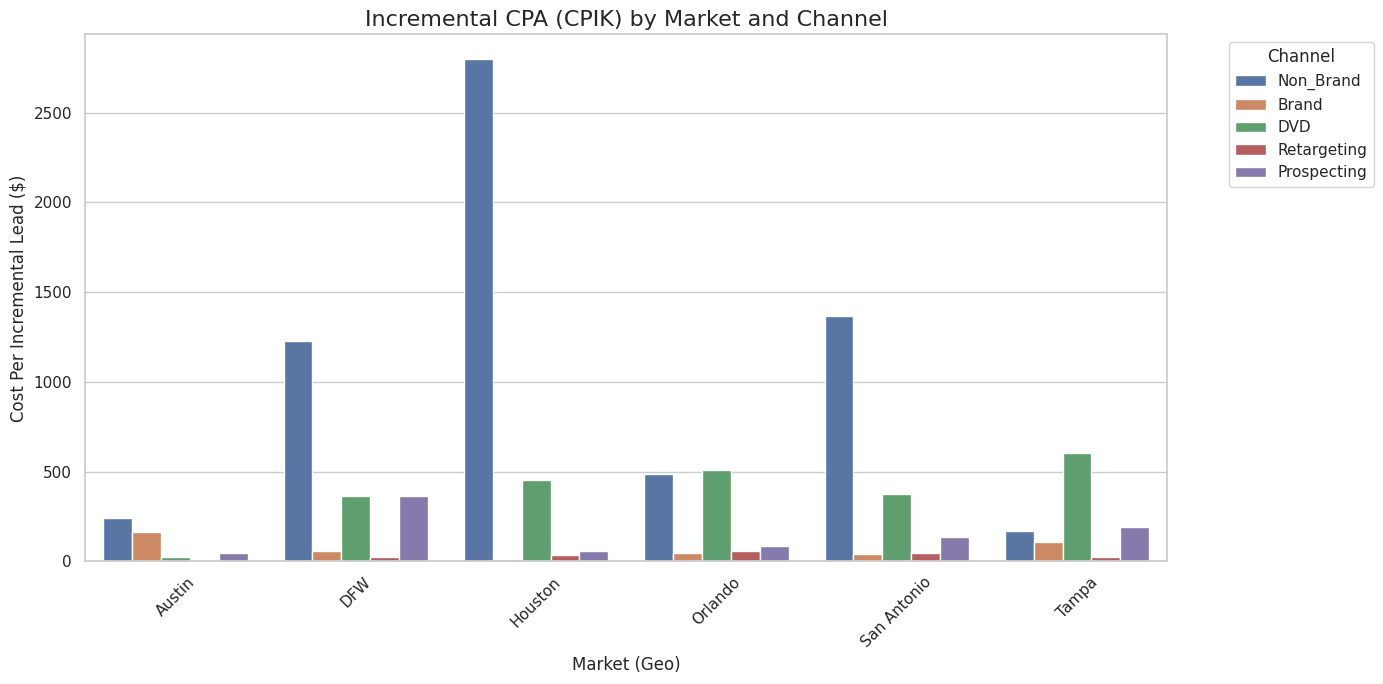

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the actual model results: Posterior Median
plot_df = geo_df[(geo_df['distribution'] == 'posterior') & (geo_df['metric'] == 'median') & (geo_df['channel'] != 'All Channels')].copy()


# Set plot style
sns.set_theme(style="whitegrid")

# --- PLOT 1: Incremental CPA by Market & Channel ---
plt.figure(figsize=(14, 7))
ax1 = sns.barplot(data=plot_df, x='geo', y='cpik', hue='channel')
plt.title('Incremental CPA (CPIK) by Market and Channel', fontsize=16)
plt.ylabel('Cost Per Incremental Lead ($)', fontsize=12)
plt.xlabel('Market (Geo)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

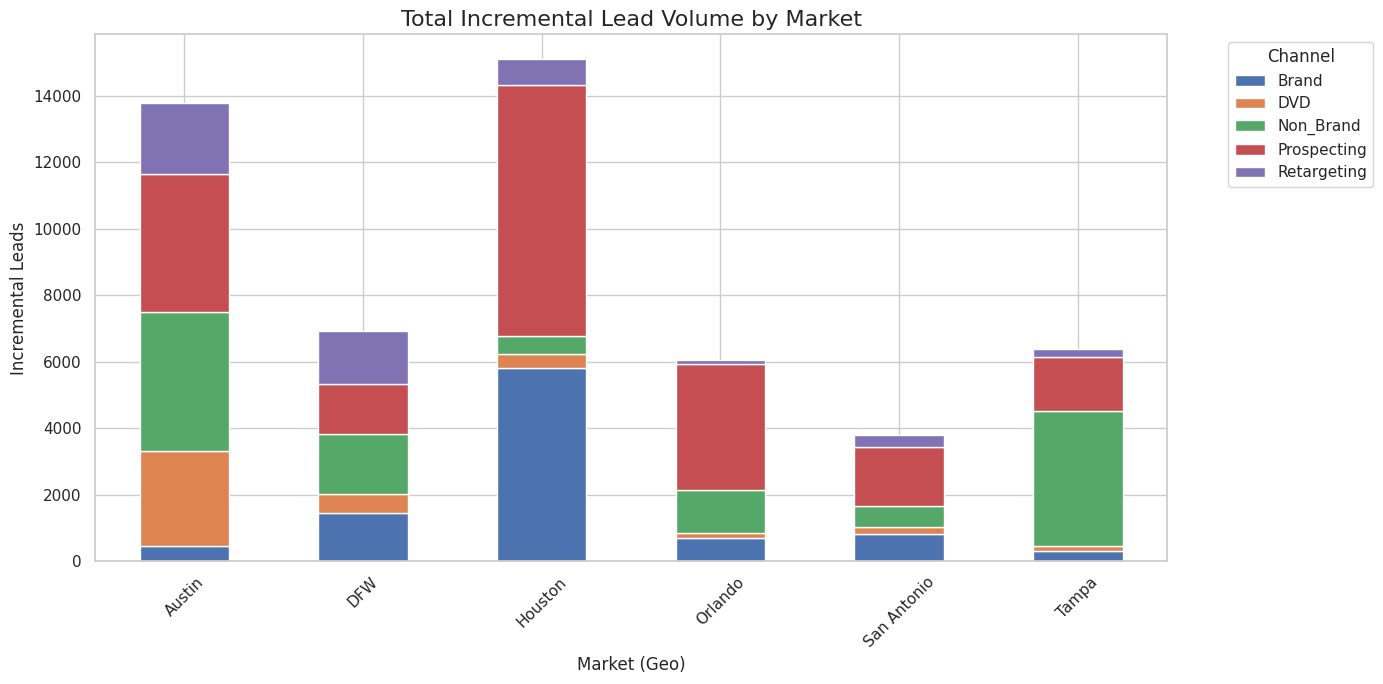

In [ ]:
pivot_df = plot_df.pivot(index='geo', columns='channel', values='incremental_outcome')

plt.figure(figsize=(14, 7))
pivot_df.plot(kind='bar', stacked=True, figsize=(14, 7), ax=plt.gca())
plt.title('Total Incremental Lead Volume by Market', fontsize=16)
plt.ylabel('Incremental Leads', fontsize=12)
plt.xlabel('Market (Geo)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

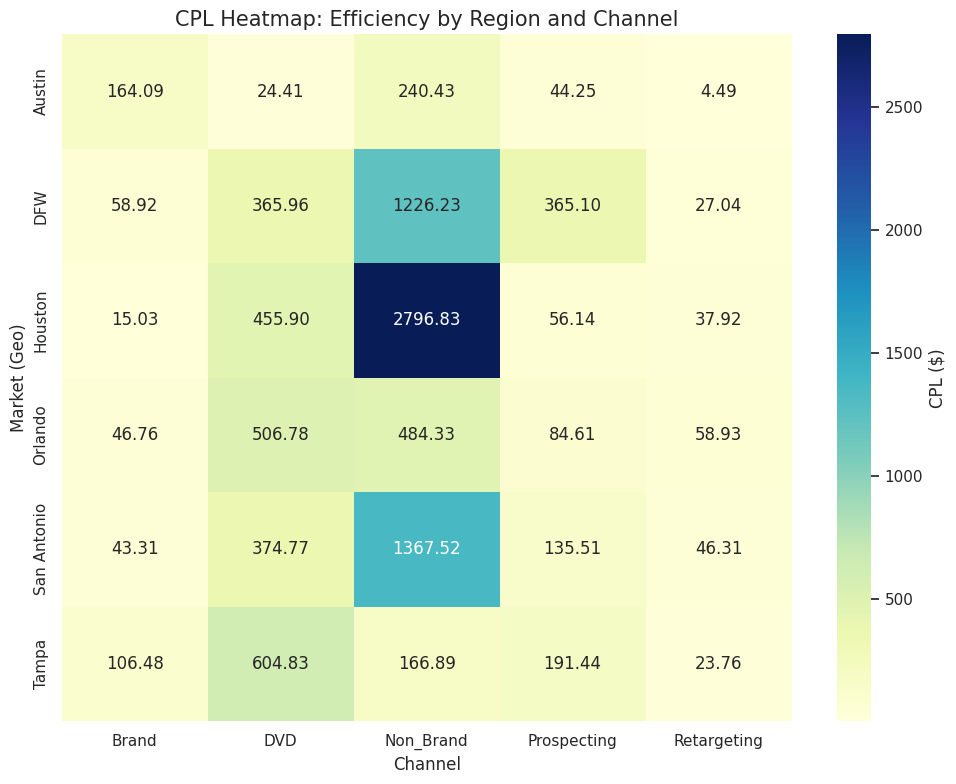

In [ ]:
# --- PLOT 3: CPA Heatmap by Region (Efficiency View) ---
heatmap_data = plot_df.pivot(index='geo', columns='channel', values='cpik')

plt.figure(figsize=(10, 8))
# We remove cbar_kws to avoid the error and set it manually below
ax = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='YlGnBu')

plt.title('CPL Heatmap: Efficiency by Region and Channel', fontsize=15)
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Market (Geo)', fontsize=12)

# Set the colorbar label manually
cbar = ax.collections[0].colorbar
cbar.set_label('CPL ($)', fontsize=12)

plt.tight_layout()
plt.show()

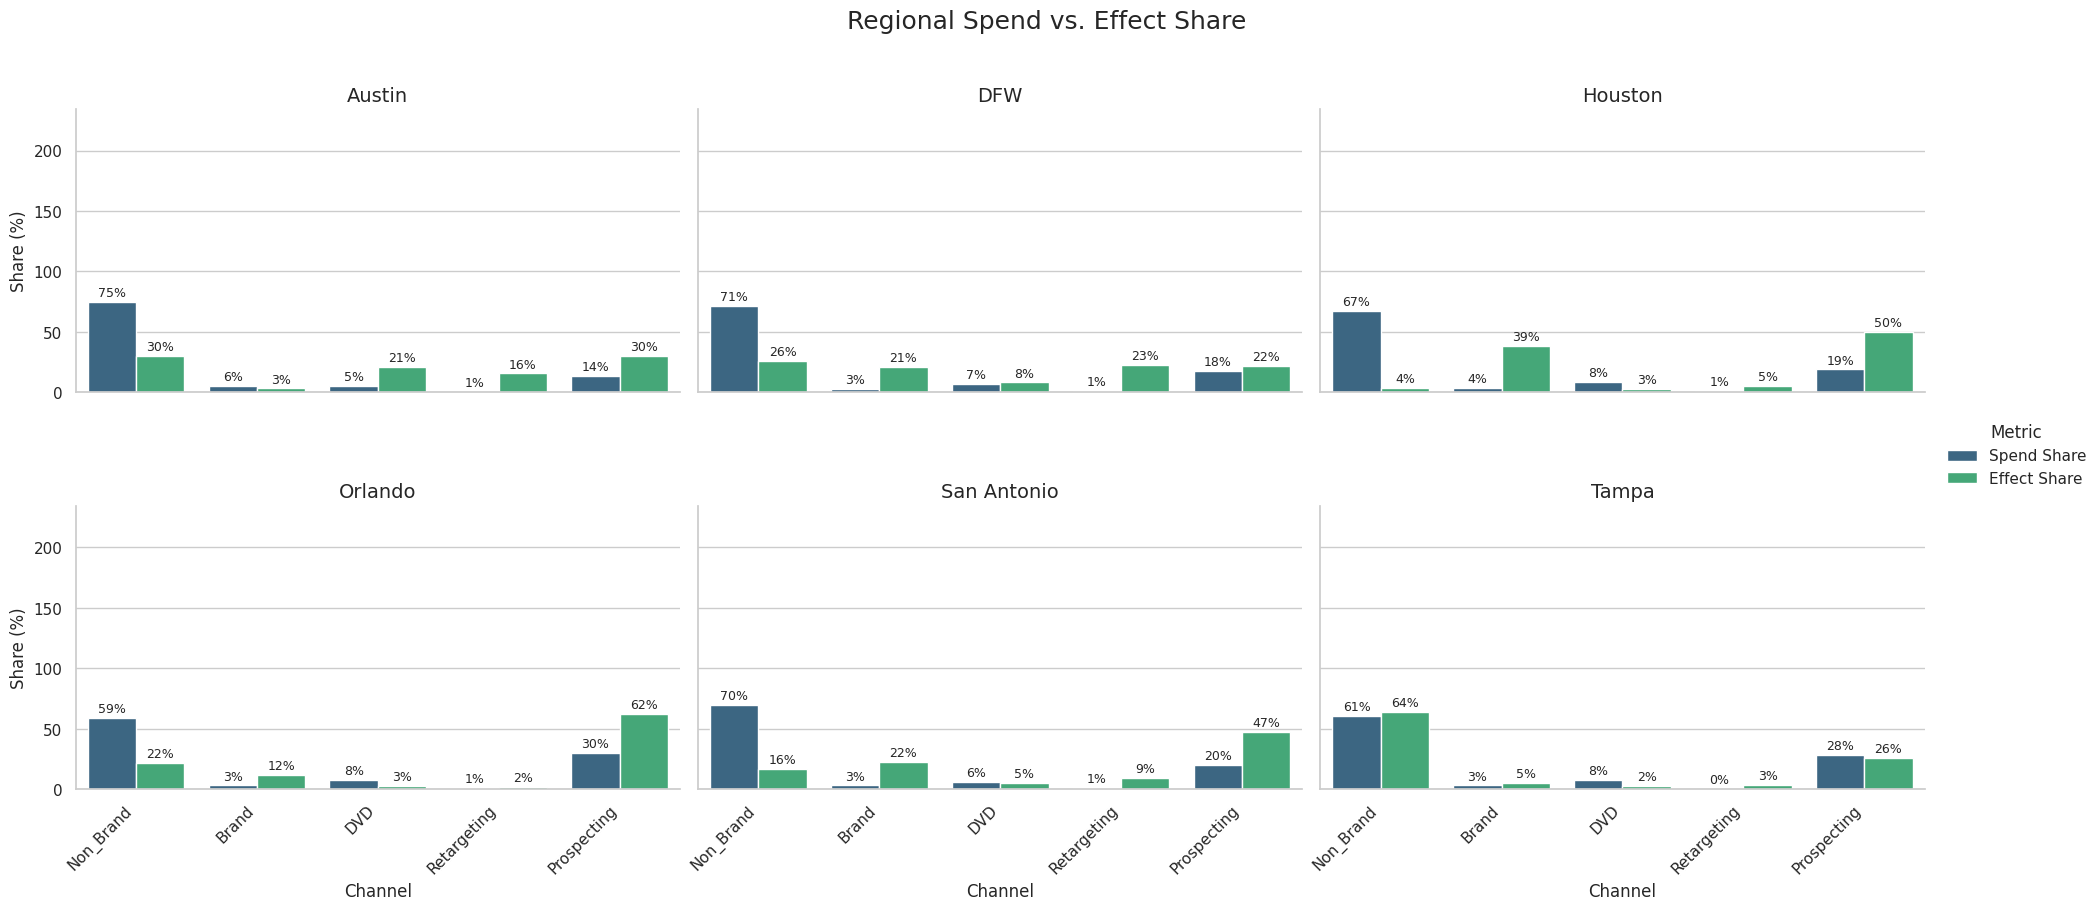

<Figure size 640x480 with 0 Axes>

In [ ]:
# 1. Calculate shares within each specific Geo
geo_totals = plot_df.groupby('geo').agg({
    'spend': 'sum',
    'incremental_outcome': 'sum'
}).rename(columns={'spend': 'total_geo_spend', 'incremental_outcome': 'total_geo_incremental'})

geo_shares = plot_df.merge(geo_totals, on='geo')
geo_shares['Spend Share'] = (geo_shares['spend'] / geo_shares['total_geo_spend']) * 100
geo_shares['Effect Share'] = (geo_shares['incremental_outcome'] / geo_shares['total_geo_incremental']) * 100

melted_geo = geo_shares.melt(
    id_vars=['geo', 'channel'],
    value_vars=['Spend Share', 'Effect Share'],
    var_name='Metric',
    value_name='Percentage'
)

# 2. Create the faceted plot
g = sns.catplot(
    data=melted_geo, kind="bar",
    x="channel", y="Percentage", hue="Metric",
    col="geo", col_wrap=3,
    palette="viridis", height=5, aspect=1.3
)

g.set_axis_labels("Channel", "Share (%)")
g.set_titles("{col_name}", size=14)

# --- ADD LABELS AND ROTATION TO EVERY SUBPLOT ---
for ax in g.axes.flat:
    # Rotate Labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Label each bar in this subplot
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', padding=2, fontsize=9)

    # Increase y-limit slightly so labels don't hit the top of the box
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

plt.subplots_adjust(top=0.88, bottom=0.2, hspace=0.4)
g.fig.suptitle('Regional Spend vs. Effect Share', fontsize=18)
plt.show()

# FIX: Add extra space at the bottom for the rotated labels
plt.subplots_adjust(top=0.88, bottom=0.2)
g.fig.suptitle('Regional Spend vs. Effect Share', fontsize=18)
plt.show()

### Budget Optimzer

In [ ]:
from meridian.analysis import optimizer

In [ ]:
# ==========================================================
# BUDGET OPTIMIZER (Meridian 1.4.0)
# ==========================================================
# Runs a fixed-budget optimization by default and returns an OptimizationResults object.

budget_optimizer = optimizer.BudgetOptimizer(mmm)

In [ ]:
# --- NATIONAL / ALL GEOS (default) ---
optimization_results = budget_optimizer.optimize(
    fixed_budget=True,                 # fixed total budget
    # Optional: restrict the optimization horizon (recommended: future-like window)
    start_date="2025-02-03",
    end_date="2025-02-24",
)

# View tables / plots
#optimization_results

# Optional: generate the optimizer HTML output (same pattern as model summary output)
optimization_results.output_optimization_summary("optimization_summary.html", "./")

IPython.display.HTML(filename="optimization_summary.html")

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  

Channel,Non-optimized spend,Optimized spend
Non_Brand,75%,68%
Prospecting,15%,19%
DVD,6%,8%
Brand,4%,5%
Retargeting,1%,1%


In [ ]:
# ==========================================================
# CAN WE LOOK AT IT BY GEO?
# Yes — scope optimization to a subset of geos using create_optimization_grid(...selected_geos=...)
# ==========================================================

# Option A (simplest): just scope directly by geo
optimization_results_geo = budget_optimizer.optimize(
    fixed_budget=True,
    selected_geos=["Tampa"],   # <- change to any geo or list of geos
    # Optional: time window (can be within data range)
    start_date="2025-02-03",
    end_date="2025-02-24",
)

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  

In [ ]:
# 1) Write the optimizer report to HTML
filename = "optimization_summary_geo.html"
optimization_results_geo.output_optimization_summary(filename, "./")

# 2) Render it inline in the notebook
IPython.display.HTML(filename=filename)

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


Channel,Non-optimized spend,Optimized spend
Non_Brand,60%,69%
Prospecting,35%,25%
Brand,4%,6%
Retargeting,0%,0%
DVD,0%,0%


### Apendix

Test Data